# 04 · Model optimization and development selection

## 1. Phase 4 objective
Select one development model and one challenger using training-only patient-grouped tuning, followed by a fixed external **validation** comparison. Average precision (AP) is primary: positive prevalence is approximately 11%, and AP focuses on retrieving positives while accounting for false positives. We also inspect ROC-AUC, Brier and threshold behavior.

The frozen test is never loaded or scored. No final threshold, SHAP, full fairness/error analysis, business optimization or deployment belongs here. [Protocol](../reports/modeling/phase4_protocol.md) and [configuration](../configs/phase4.yaml) were fixed before fitting.

All training and evaluation use reusable `src/` modules. On rerun, verified training/model artifacts and the single saved validation prediction pass are reused. Fresh reproduction performs the complete prespecified search; it never substitutes a smaller CI search.

In [1]:
import json
import warnings

import pandas as pd
from IPython.display import Image, Markdown, display
from tqdm import TqdmWarning

# Only silence the optional progress-widget warning during MLflow imports.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)
    from readmit_iq.optimization.contract import settings, verify_contract
    from readmit_iq.optimization.evaluate import evaluate
    from readmit_iq.optimization.fit import fit_candidates
    from readmit_iq.optimization.reports import build_reports

root, policy = settings()
out = root / policy["report_dir"]
figures = root / policy["figure_dir"]
pd.set_option("display.max_columns", 14)
pd.set_option("display.precision", 6)


def table(name):
    return pd.read_csv(out / name)


def figure(name):
    display(Image(filename=str(figures / name), width=1000))

## 2. Frozen development contract
Prediction occurs at **confirmed discharge once destination is known**. The primary schema includes age, gender, admission type/source, destination, specialty, length of stay and prior-year utilization counts. IDs, outcome variables, race, future-derived histories, constants and sparse weight are excluded. Diagnoses remain timing-uncertain sensitivities.

The check below hashes existing bytes and parses only the assignment-key inventory to verify isolation. Counts come from the original freeze record; no test table or test outcomes are reopened. Missing/changed partitions fail without reconstruction.

In [2]:
frozen = verify_contract(root)
assert frozen["eligible_encounters"] == 90702
assert all(value == 0 for value in frozen["patient_overlap"].values())
display(
    pd.DataFrame(frozen["partitions"])[["partition", "encounters", "patients", "prevalence_pct"]]
)
display(pd.Series(frozen["files"], name="Verified frozen SHA-256").to_frame())
print("Patient overlap: zero. Test: locked; integrity hashing only.")

,partition,encounters,patients,prevalence_pct
0,train,63563,45530,11.119677
1,validation,13590,9757,11.030169
2,test,13549,9757,10.974980


,Verified frozen SHA-256
assignments.csv.gz,11b732c0865bb1e52e404c0d3b2896682d0685ef931f7d...
test.csv.gz,04816664930093cf38b0c2dee1caaeb4097272bbc861a6...
train.csv.gz,571d8111634552bbc314eaa227ef4ab4db72edfa6f51b2...
validation.csv.gz,1eaea4186167bade6d37eb7e48e539551e0b960879501c...


Patient overlap: zero. Test: locked; integrity hashing only.


## 3. Group-aware CV
Five `StratifiedGroupKFold` folds use shuffle and seed 42 on canonical encounter ordering. Each patient stays in one holdout fold. Every fold checks both classes, prevalence within 0.01 of training prevalence, complete coverage and zero patient overlap. Category pooling, encoding and scaling fit inside each training fold.

The next call runs or verifies the complete training stage: controlled feature comparisons, bounded Optuna searches, one fixed forest reference, final training-only fits and cross-fitted calibrators. It seals all seven models before any validation access. Shared folds support matched comparisons, but selected CV scores are optimistic because this is **not nested CV**.

In [3]:
fitted = fit_candidates()
training = json.loads((out / "training_selection.json").read_text())
assert not fitted["validation_opened"] and not fitted["test_evaluated"]
assert fitted["calibration_partition"] == "train"
assert fitted["fold_membership_sha256"] == training["fold_membership_sha256"]
folds = table("cv_folds.csv")
assert folds.patient_overlap.eq(0).all()
display(folds.loc[folds.role.eq("holdout")])
print("Training stage sealed:", len(fitted["models"]), "models")

,fold,role,encounters,patients,positives,prevalence,patient_overlap
1,0,holdout,12713,9113,1414,0.111225,0
3,1,holdout,12712,9117,1414,0.111233,0
5,2,holdout,12713,9152,1413,0.111146,0
7,3,holdout,12712,9085,1413,0.111155,0
9,4,holdout,12713,9063,1414,0.111225,0


Training stage sealed: 7 models


## 4. Logistic tuning
Unweighted L2/lbfgs logistic tunes `C` on [0.001, 100] with log sampling. The compact primary design does not justify a larger solver/penalty search. Sequential Optuna TPE uses seed 42; baseline parameters enter trial 0. Maximum 30 trials, minimum 15; stop after 10 trials without at least 0.0002 AP improvement. No class-weight search or SMOTE.

In [4]:
lr = training["selected"]["logistic"]
display(pd.Series({k: v for k, v in lr.items() if k != "parameters"}).to_frame("Logistic"))
display(pd.Series(lr["parameters"]).to_frame("Selected parameter"))

,Logistic
configuration,raw
cv_average_precision_mean,0.212434
cv_average_precision_sd,0.00768
cv_roc_auc_mean,0.658876
cv_roc_auc_sd,0.00795
cv_brier_mean,0.095093
cv_brier_sd,0.000508
cv_recall_mean,0.019383
cv_recall_sd,0.002766
cv_precision_mean,0.495189


,Selected parameter
C,0.099882


## 5. Gradient boosting tuning
Histogram boosting tunes learning rate [0.025, 0.15] (log), iterations {75,125,150,200,300}, leaves {7,15,31}, minimum leaf {20,30,50,100,200}, L2 {0,0.1,1,10,30}. Depth is unset and max bins stays 255. Internal early stopping is disabled; patient-grouped CV chooses complexity. Maximum 50 trials, minimum 25; patience 15 at the same 0.0002 AP margin.

Random forest is one fixed 200-tree, depth-12, minimum-leaf-20 reference. All experiments use two numerical threads. Trial parameters, durations, fold metrics and Git/seed provenance are tracked in local MLflow SQLite; its directory is ignored by Git.

In [5]:
gb = training["selected"]["boosting"]
display(pd.Series({k: v for k, v in gb.items() if k != "parameters"}).to_frame("Boosting"))
display(pd.Series(gb["parameters"]).to_frame("Selected parameter"))
trials = table("optuna_trials.csv")
display(trials.groupby("family").agg(completed_trials=("trial", "count")))

,Boosting
configuration,raw
cv_average_precision_mean,0.220207
cv_average_precision_sd,0.005272
cv_roc_auc_mean,0.663868
cv_roc_auc_sd,0.008214
cv_brier_mean,0.094488
cv_brier_sd,0.00029
cv_recall_mean,0.002687
cv_recall_sd,0.004594
cv_precision_mean,0.238947


,Selected parameter
learning_rate,0.049386
max_iter,75.000000
max_leaf_nodes,15.000000
min_samples_leaf,50.000000
l2_regularization,30.000000


,completed_trials
family,
boosting,30
logistic,15


## 6. Feature configuration comparison
Both families compare raw counts, indicators only, raw + engineered utilization, grouped diagnoses and controlled raw diagnoses at fixed baseline settings. Raw is preferred if within the prespecified 0.001 AP margin of the best eligible configuration. Diagnosis variants remain **ineligible** for primary selection, irrespective of CV performance. No validation data selects these configurations.

In [6]:
features = table("feature_comparison.csv")
display(
    features[
        [
            "family",
            "configuration",
            "cv_average_precision_mean",
            "cv_average_precision_sd",
            "eligible",
        ]
    ]
)
print(
    "Selected features:",
    {name: item["configuration"] for name, item in training["selected"].items()},
)

,family,configuration,cv_average_precision_mean,cv_average_precision_sd,eligible
0,logistic,raw,0.212191,0.008265,True
1,logistic,indicators,0.182266,0.006331,True
2,logistic,raw_engineered,0.211126,0.007796,True
3,logistic,diagnosis_grouped,0.212213,0.007699,False
4,logistic,diagnosis_raw,0.213028,0.006965,False
5,boosting,raw,0.218772,0.004638,True
6,boosting,indicators,0.192949,0.003775,True
7,boosting,raw_engineered,0.219738,0.004828,True
8,boosting,diagnosis_grouped,0.224065,0.006758,False
9,boosting,diagnosis_raw,0.212723,0.007984,False


Selected features: {'logistic': 'raw', 'boosting': 'raw', 'forest': 'raw'}


## 7. Validation comparison
All seven fixed candidates are scored once on the 13,590 validation encounters. Existing Phase 3 predictions provide historical references; no new parameters are tried after seeing these results. Subsequent execution verifies model/prediction hashes and recomputes summaries from the same cached predictions.

The Phase 3 logistic comparison uses its raw-utilization ablation. Phase 3 boosting used raw + engineered utilization, so that comparison combines tuning and feature selection. Calibration and development selection now use this validation evidence; it is not an unbiased final estimate.

,average_precision,roc_auc,brier,recall,precision,f1
model,,,,,,
logistic__uncalibrated,0.196781,0.654593,0.095065,0.006671,0.322581,0.013072
boosting__uncalibrated,0.198721,0.661488,0.094604,0.000667,1.000000,0.001333
forest__uncalibrated,0.199690,0.660228,0.094797,0.000000,0.000000,0.000000
phase3_logistic_raw,0.196410,0.653037,0.095083,0.006671,0.312500,0.013063
phase3_boosting,0.202180,0.662312,0.094497,0.004670,0.538462,0.009259


Recall, precision and F1 above use 0.50 only as a reference.


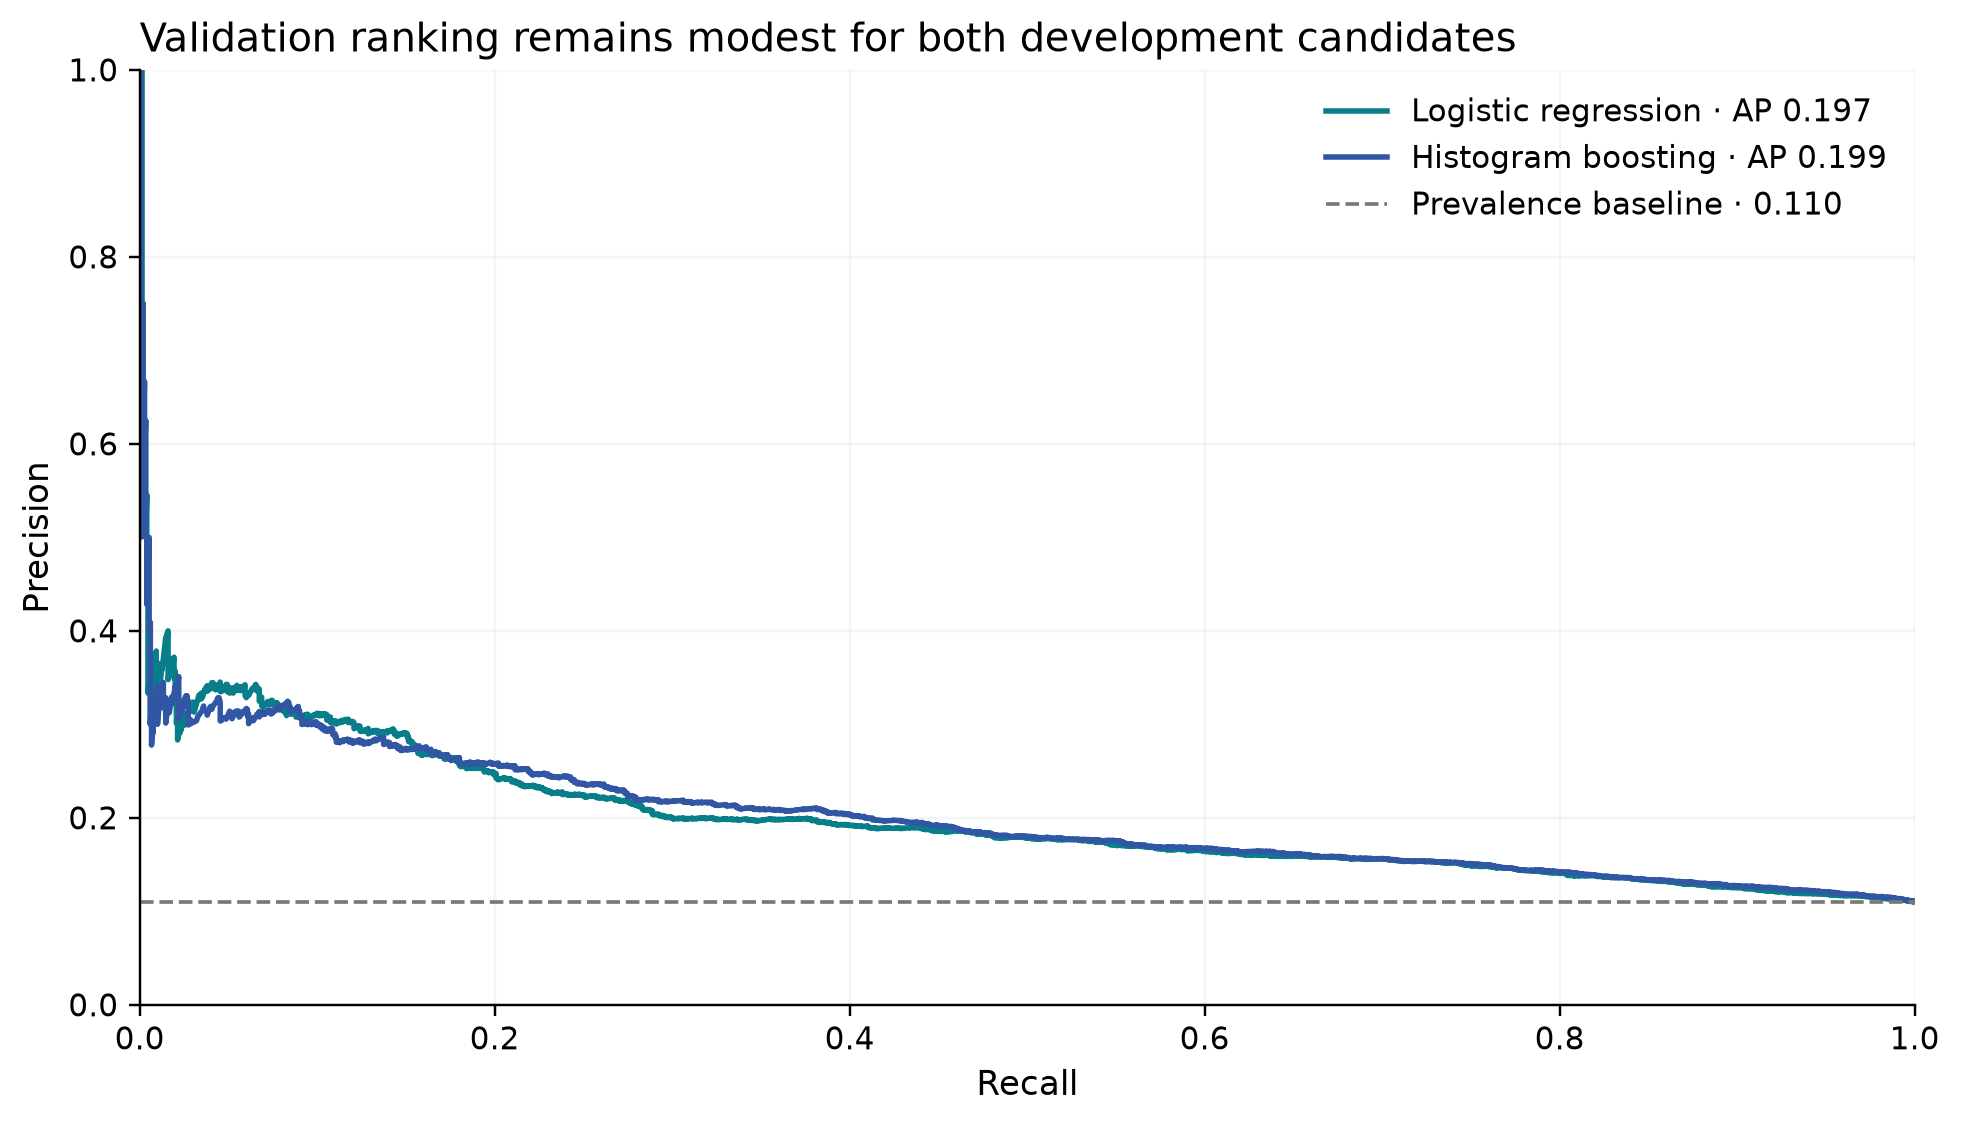

In [7]:
summary = evaluate()
artifacts = build_reports()
assert summary["evaluated_partition"] == "validation"
assert summary["validation_score_passes"] == 1 and not summary["test_evaluated"]
metrics = table("validation_metrics.csv").set_index("model")
names = [
    summary["primary"],
    summary["challenger"],
    "forest__uncalibrated",
    "phase3_logistic_raw",
    "phase3_boosting",
]
display(metrics.loc[names, ["average_precision", "roc_auc", "brier", "recall", "precision", "f1"]])
print("Recall, precision and F1 above use 0.50 only as a reference.")
figure("02_validation_precision_recall.png")

## 8. Calibration analysis
Sigmoid and isotonic fit out-of-fold responses from the same five training-only patient-grouped folds (`ensemble=False`); their base pipeline refits all training rows. Validation labels never fit a calibrator. Tuning used the same training population, so cross-fitted responses are conditional on parameter selection.

Retain calibration only if Brier improves by at least 0.0001, its paired Brier interval is entirely below zero, and AP loss is no greater than 0.001. Compare quantile reliability bins as well as mean risk/prevalence; matching the mean alone does not establish calibration. CV metrics refer to the base estimator, not an independently evaluated full calibration-selection procedure.

,average_precision,roc_auc,brier,mean_probability,prevalence
model,,,,,
logistic__uncalibrated,0.196781,0.654593,0.095065,0.109141,0.110302
logistic__sigmoid,0.196781,0.654593,0.095055,0.109145,0.110302
logistic__isotonic,0.190778,0.653456,0.094829,0.109432,0.110302
boosting__uncalibrated,0.198721,0.661488,0.094604,0.109478,0.110302
boosting__sigmoid,0.198721,0.661488,0.094620,0.109815,0.110302
boosting__isotonic,0.192512,0.660597,0.094748,0.109779,0.110302


,model,reference,ap_difference,brier_difference,ap_ci_low,ap_ci_high,brier_ci_low,brier_ci_high
0,logistic__sigmoid,logistic__uncalibrated,0.000000,-0.000010,0.000000,0.000000,-0.000023,0.000003
1,logistic__isotonic,logistic__uncalibrated,-0.006002,-0.000236,-0.008254,-0.003832,-0.000432,-0.000056
2,boosting__sigmoid,boosting__uncalibrated,0.000000,0.000016,0.000000,0.000000,-0.000049,0.000072
3,boosting__isotonic,boosting__uncalibrated,-0.006210,0.000144,-0.008237,-0.004263,0.000021,0.000264


,model,bin,encounters,mean_probability,observed_rate,positives
0,logistic__uncalibrated,"(0.030600000000000002, 0.0658]",1359,0.057610,0.047829,65
1,logistic__uncalibrated,"(0.0658, 0.0731]",1359,0.069967,0.058131,79
2,logistic__uncalibrated,"(0.0731, 0.0792]",1381,0.076265,0.062998,87
3,logistic__uncalibrated,"(0.0792, 0.0844]",1337,0.081823,0.071803,96
4,logistic__uncalibrated,"(0.0844, 0.0903]",1359,0.087005,0.086093,117
...,...,...,...,...,...,...
64,forest__uncalibrated,"(0.0965, 0.11]",1359,0.102880,0.100809,137
65,forest__uncalibrated,"(0.11, 0.124]",1359,0.116711,0.125092,170
66,forest__uncalibrated,"(0.124, 0.141]",1359,0.132159,0.133186,181
67,forest__uncalibrated,"(0.141, 0.17]",1359,0.153918,0.174393,237


Methods retained: {'logistic': 'logistic__uncalibrated', 'boosting': 'boosting__uncalibrated'}


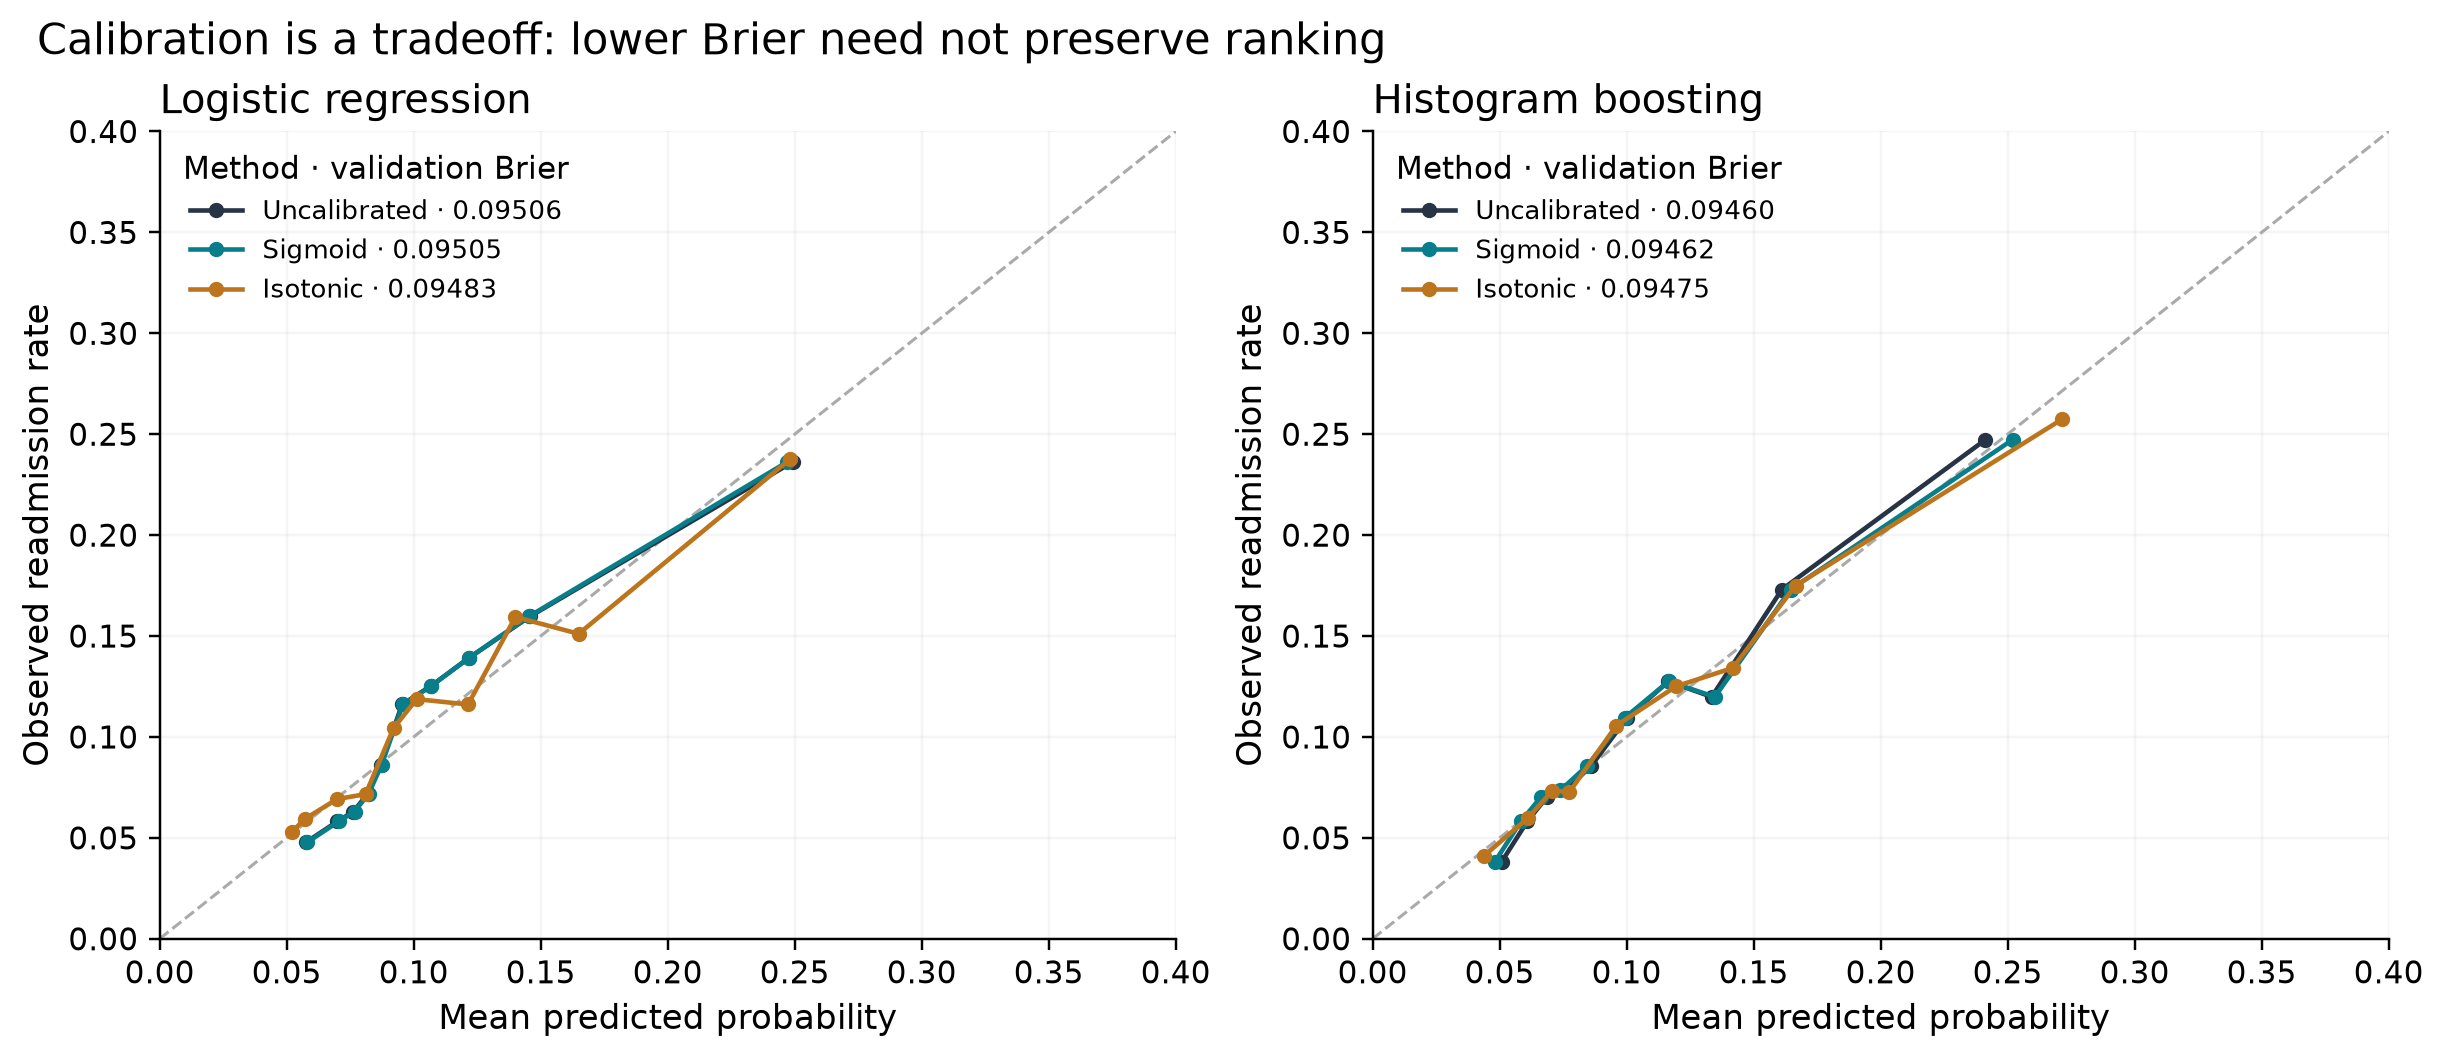

In [8]:
cal = metrics.loc[metrics.family.isin(["logistic", "boosting"])]
display(cal[["average_precision", "roc_auc", "brier", "mean_probability", "prevalence"]])
comparisons = table("paired_comparisons.csv")
display(comparisons.loc[comparisons.model.str.endswith(("__sigmoid", "__isotonic"))])
display(table("calibration_bins.csv"))
print("Methods retained:", summary["family_choices"])
figure("03_calibration_comparison.png")

## 9. Threshold behavior
A fixed 0.00–1.00 grid explores validation recall, precision, F1, specificity and flags. No threshold is optimized or selected. Unique patients flagged means anyone with at least one flagged encounter anywhere in the historical validation extract; without dates it is not a simultaneous outreach caseload. The chart shows 0.00–0.40 for readability; the CSV contains the full grid.

,model,threshold,recall,precision,f1,specificity,encounters_flagged,encounter_fraction_flagged,patients_flagged,patient_fraction_flagged
5,logistic__uncalibrated,0.05,0.995330,0.111535,0.200592,0.017037,13377,0.984327,9577,0.981552
10,logistic__uncalibrated,0.10,0.606404,0.163079,0.257034,0.614176,5574,0.410155,3608,0.369786
15,logistic__uncalibrated,0.15,0.267512,0.219967,0.241421,0.882392,1823,0.134143,1144,0.117249
20,logistic__uncalibrated,0.20,0.162108,0.268212,0.202079,0.945166,906,0.066667,588,0.060264
30,logistic__uncalibrated,0.30,0.056704,0.335968,0.097032,0.986105,253,0.018617,142,0.014554
50,logistic__uncalibrated,0.50,0.006671,0.322581,0.013072,0.998263,31,0.002281,14,0.001435
106,boosting__uncalibrated,0.05,0.992662,0.113242,0.203293,0.036308,13140,0.966887,9369,0.960234
111,boosting__uncalibrated,0.10,0.657105,0.160711,0.258259,0.574560,6129,0.450993,3946,0.404428
116,boosting__uncalibrated,0.15,0.346231,0.209021,0.260673,0.837565,2483,0.182708,1552,0.159065
121,boosting__uncalibrated,0.20,0.168112,0.268943,0.206897,0.943346,937,0.068948,567,0.058112


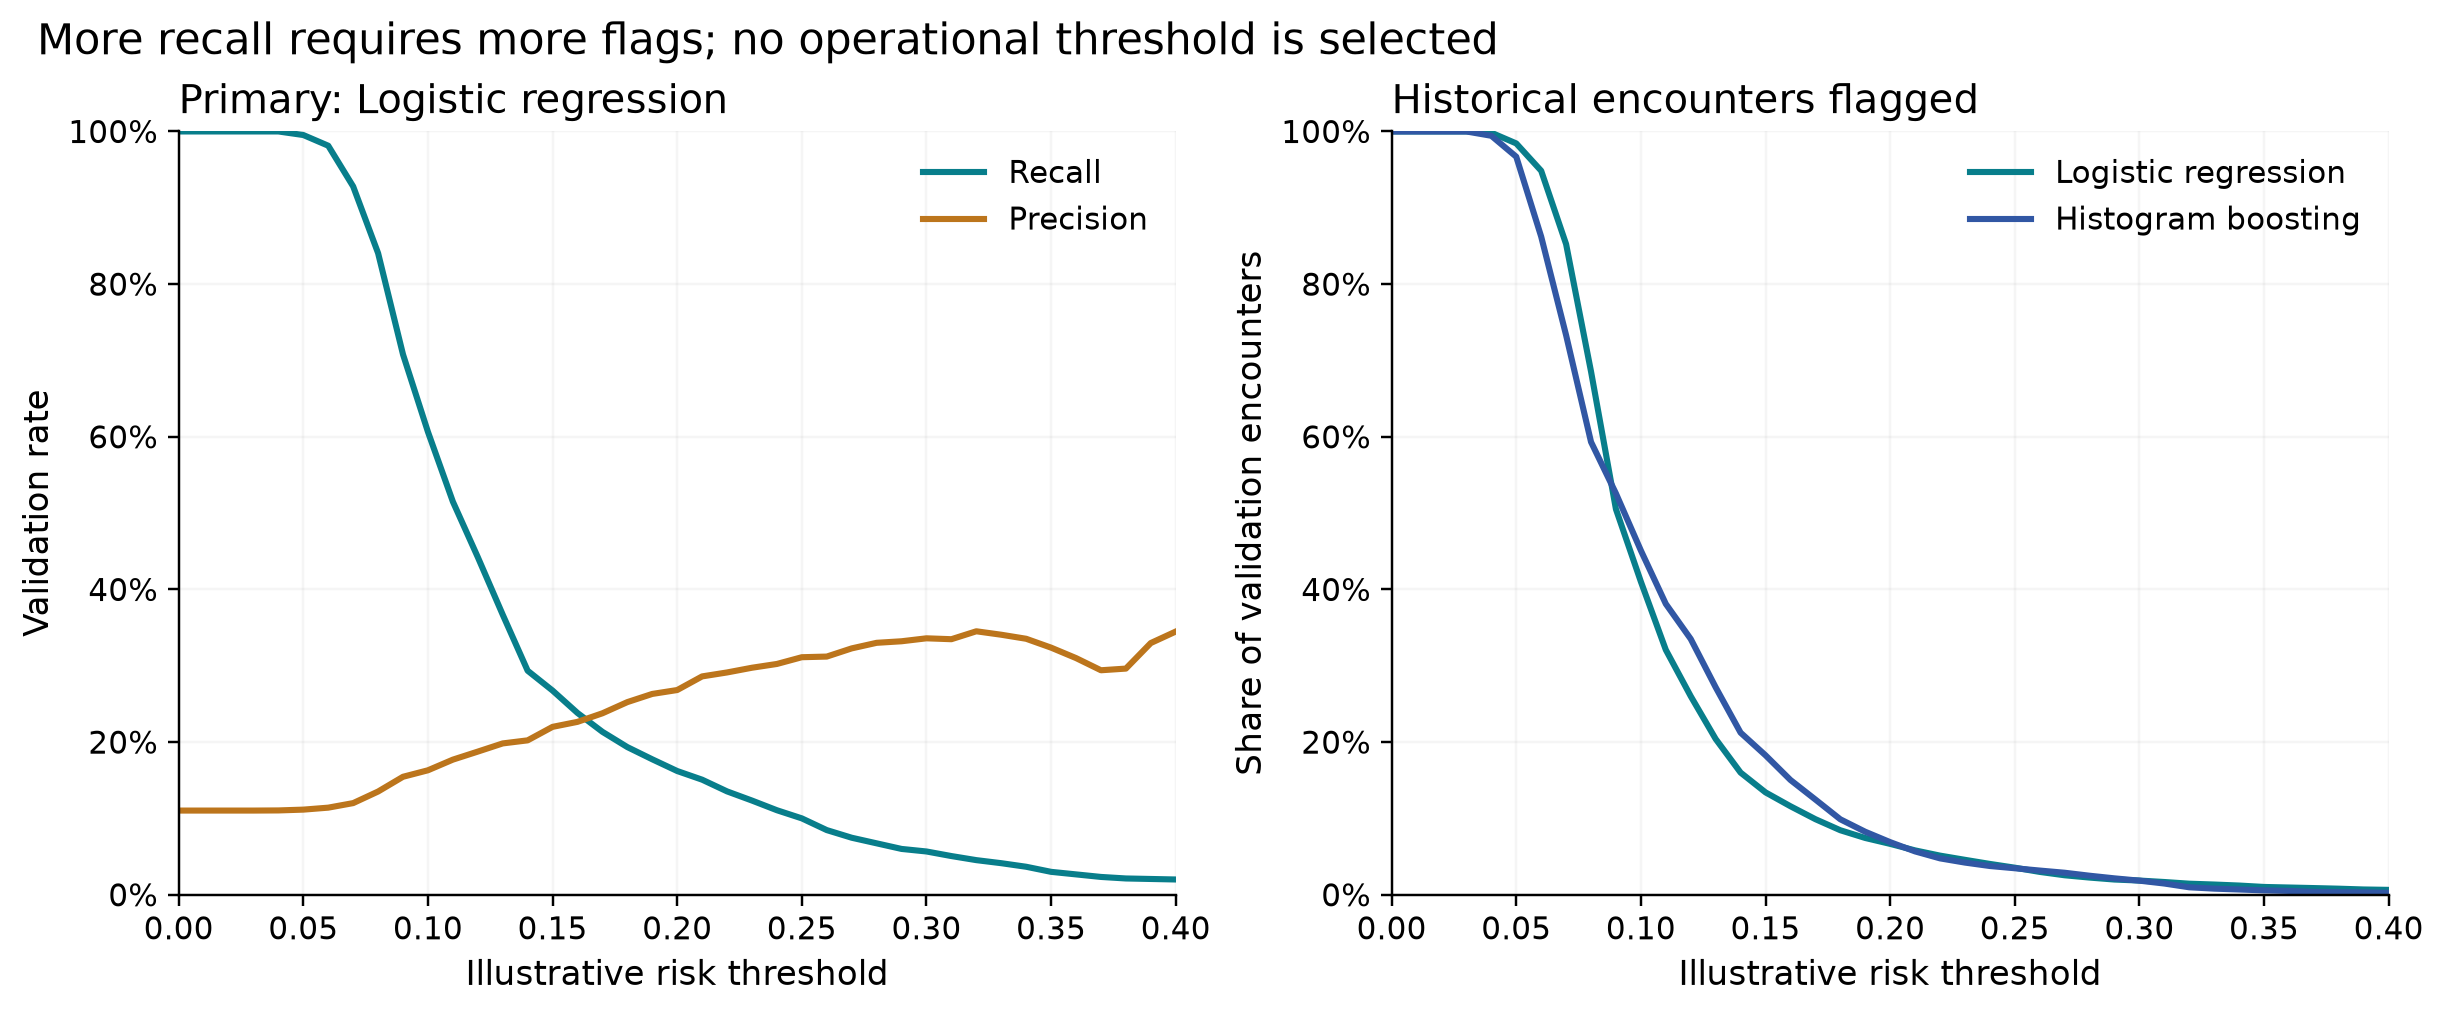

In [9]:
thresholds = table("thresholds.csv")
display(
    thresholds.loc[
        thresholds.threshold.isin([0.05, 0.10, 0.15, 0.20, 0.30, 0.50]),
        [
            "model",
            "threshold",
            "recall",
            "precision",
            "f1",
            "specificity",
            "encounters_flagged",
            "encounter_fraction_flagged",
            "patients_flagged",
            "patient_fraction_flagged",
        ],
    ]
)
assert not summary["threshold_selected"]
figure("04_threshold_behavior.png")

## 10. Model stability and feature complexity
AP means, sample SDs and fold minima/maxima describe variation across patient groups. Five overlapping training folds are not five independent experiments. Compare the same holdouts rather than declaring every small mean difference meaningful. Encoded dimensions differ in interpretation between one-hot logistic and native-categorical boosting.

,configuration,cv_average_precision_mean,cv_average_precision_sd,cv_ap_min,cv_ap_max
logistic,raw,0.212434,0.00768,0.205121,0.225514
boosting,raw,0.220207,0.005272,0.212383,0.227111
forest,raw,0.217605,0.005375,0.211854,0.223439


,family,configuration,reference,mean_ap_difference,sd_ap_difference,min_ap_difference,max_ap_difference
0,boosting,raw_engineered,raw,0.000967,0.001259,-0.000665,0.002598
1,boosting,indicators,raw,-0.025822,0.005324,-0.030750,-0.017357
2,boosting,diagnosis_grouped,raw,0.005293,0.002833,0.000769,0.008346
3,boosting,diagnosis_raw,raw,-0.006048,0.006000,-0.011701,0.001924
4,boosting,diagnosis_raw,diagnosis_grouped,-0.011342,0.004271,-0.016417,-0.004887
5,logistic,raw_engineered,raw,-0.001065,0.001407,-0.002710,0.000646
6,logistic,indicators,raw,-0.029926,0.005735,-0.036404,-0.023739
7,logistic,diagnosis_grouped,raw,0.000022,0.001393,-0.001957,0.001226
8,logistic,diagnosis_raw,raw,0.000836,0.006490,-0.007779,0.008184
9,logistic,diagnosis_raw,diagnosis_grouped,0.000815,0.006170,-0.006858,0.007427


,family,configuration,min_encoded_features,max_encoded_features
0,boosting,diagnosis_grouped,14,14
1,boosting,diagnosis_raw,14,14
2,boosting,indicators,10,10
3,boosting,raw,10,10
4,boosting,raw_engineered,14,14
5,logistic,diagnosis_grouped,113,114
6,logistic,diagnosis_raw,339,345
7,logistic,indicators,76,77
8,logistic,raw,76,77
9,logistic,raw_engineered,80,81


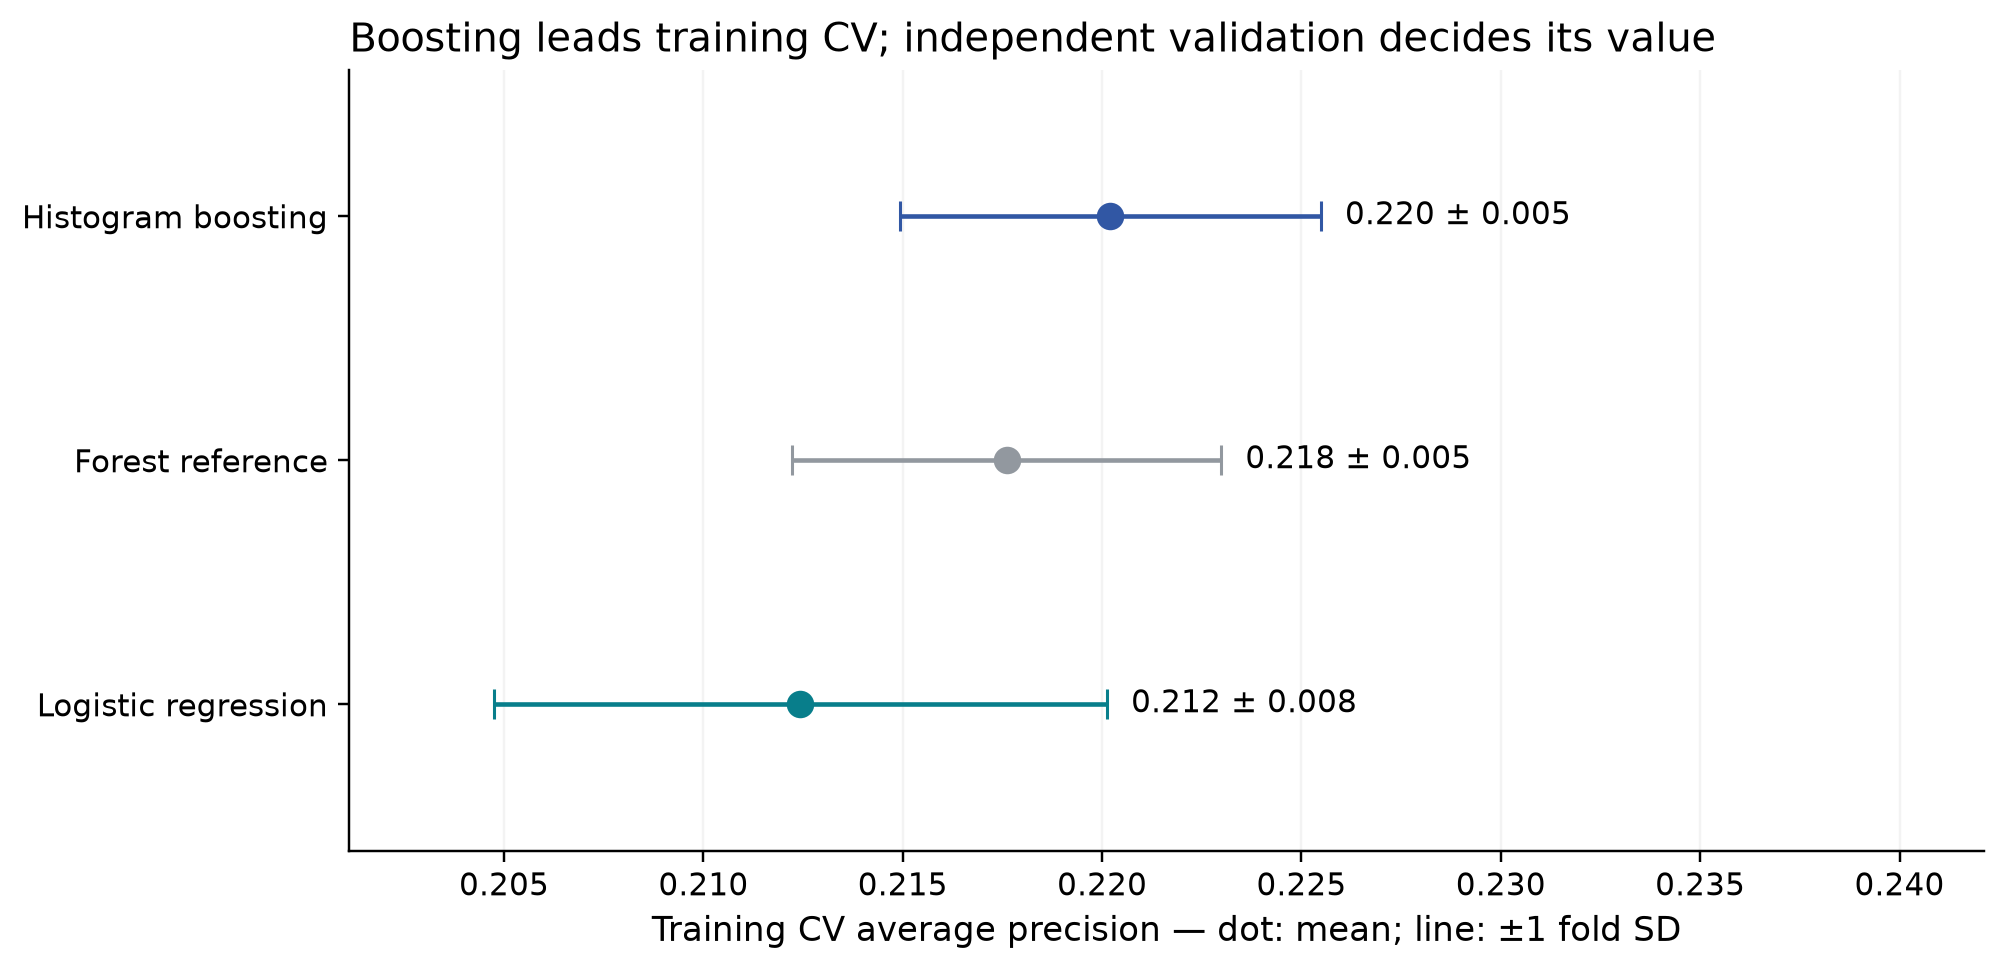

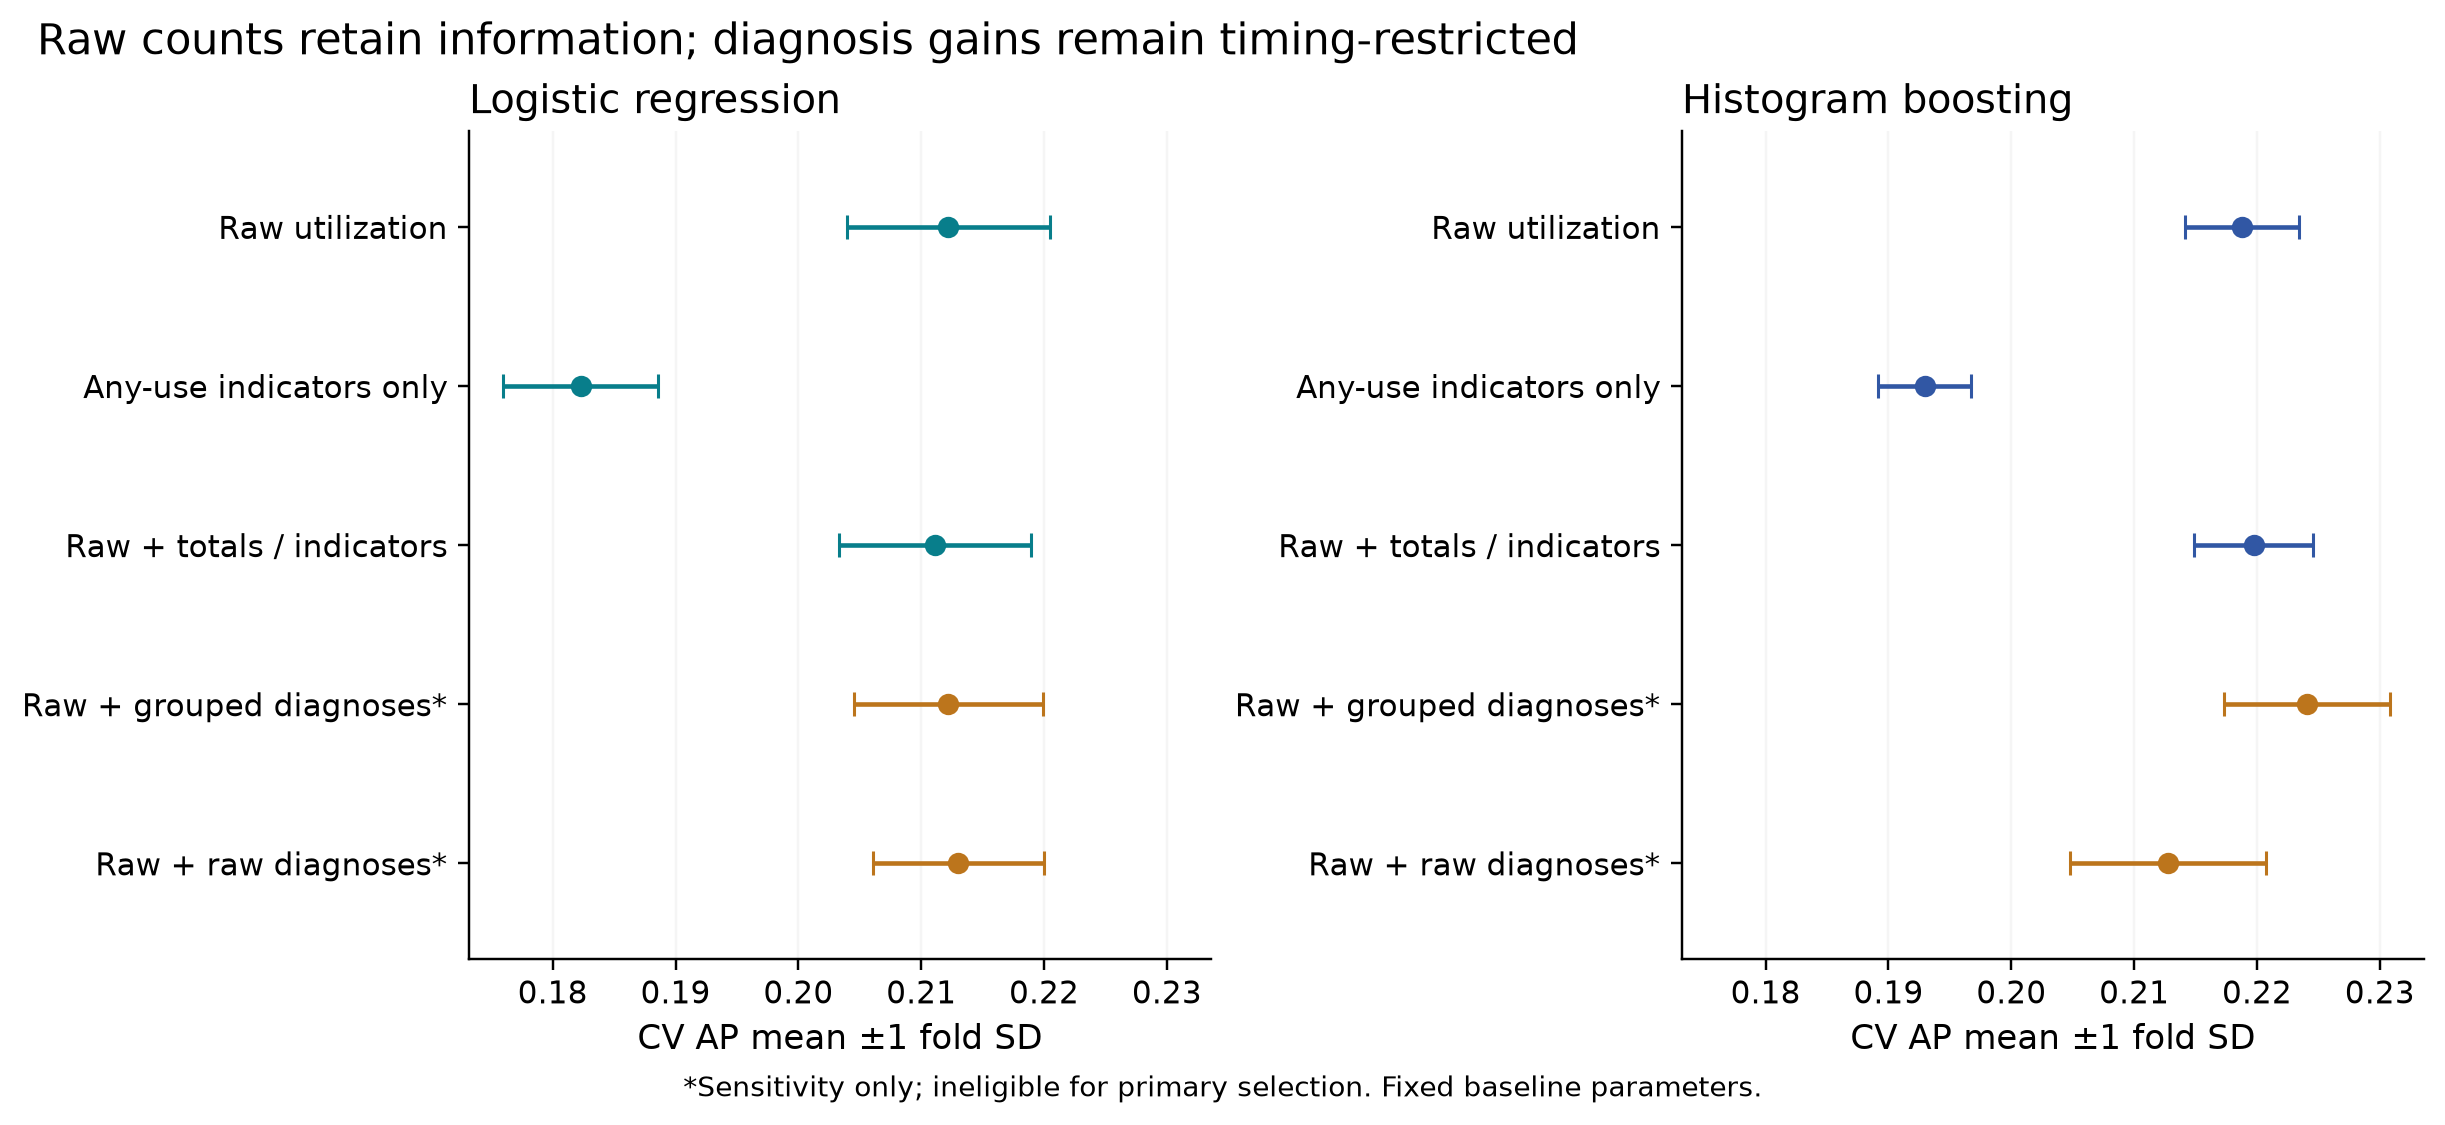

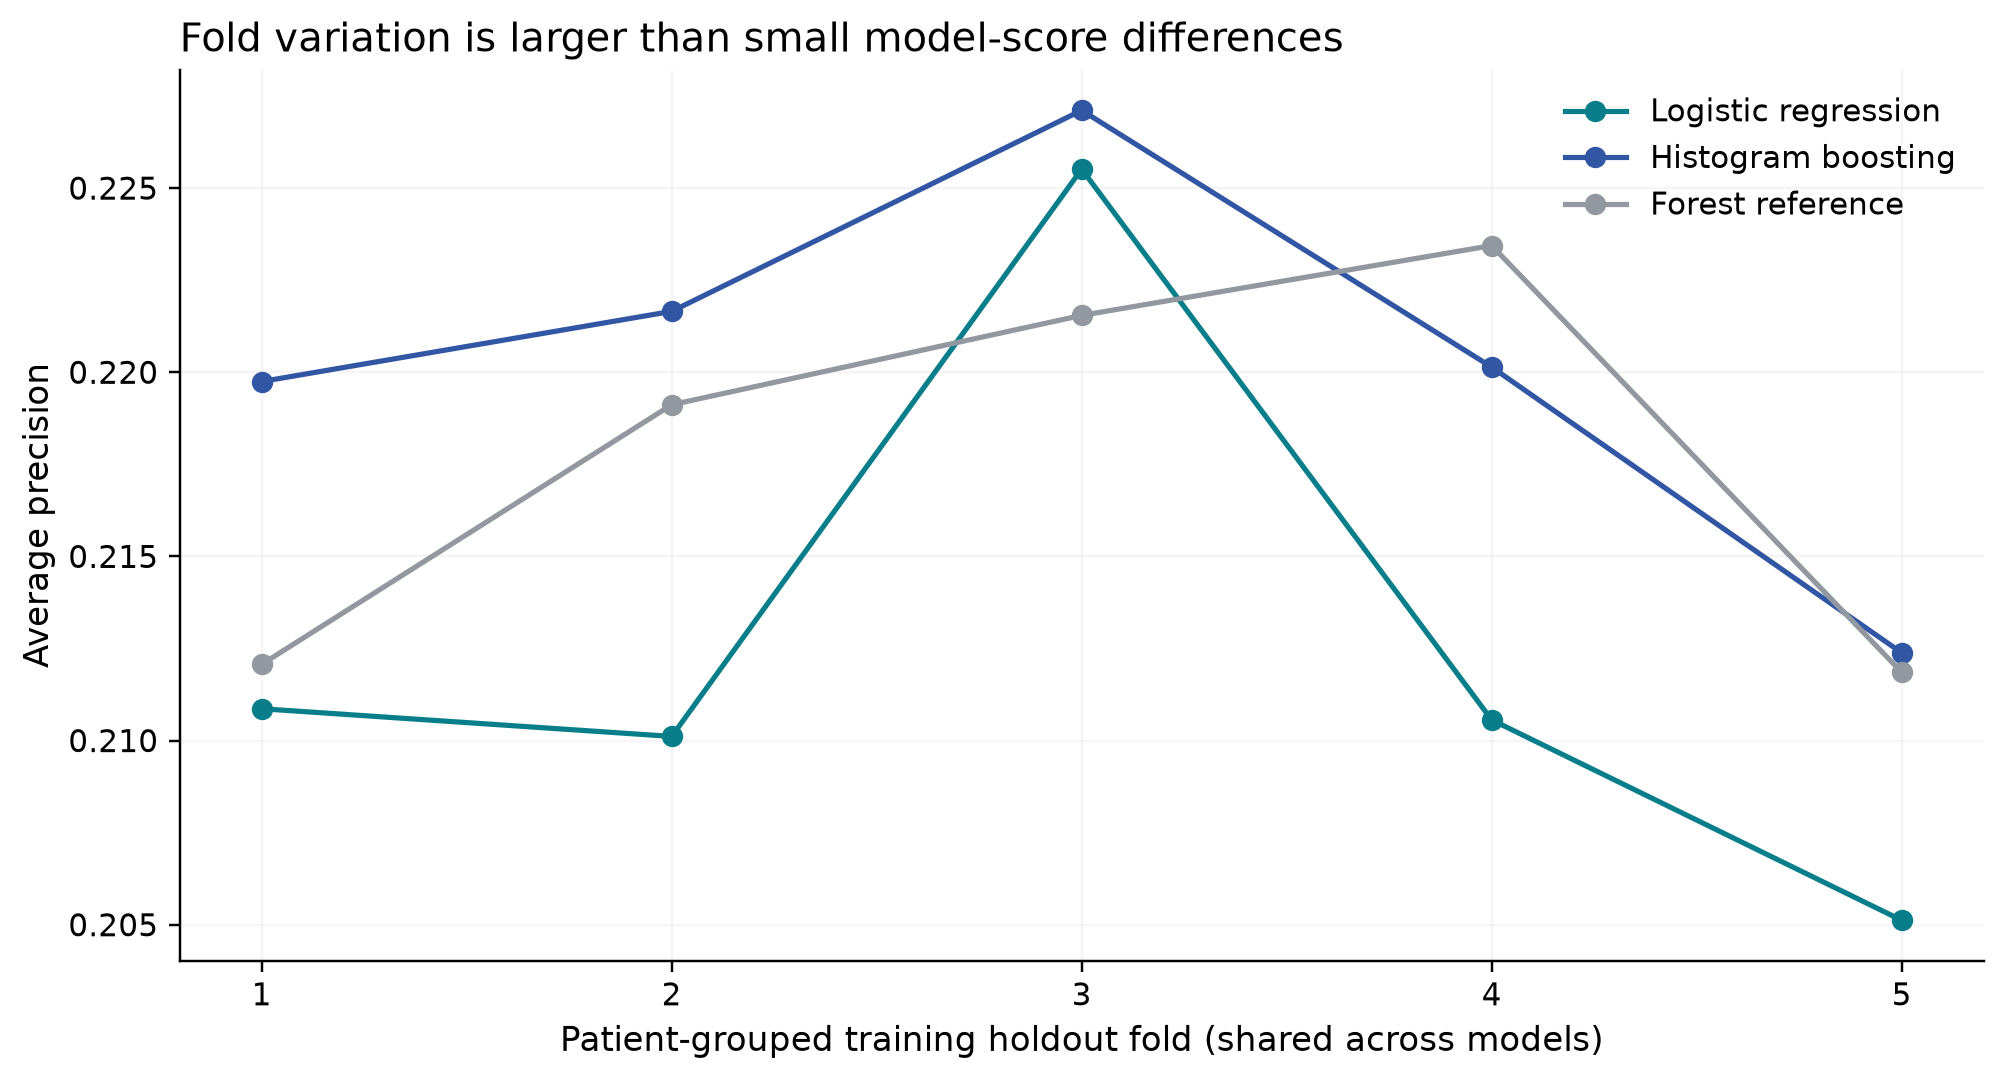

In [10]:
stability = pd.DataFrame(training["selected"]).T
columns = [
    "configuration",
    "cv_average_precision_mean",
    "cv_average_precision_sd",
    "cv_ap_min",
    "cv_ap_max",
]
display(stability[columns])
display(table("feature_paired_fold_differences.csv"))
display(table("feature_dimensions.csv"))
figure("01_cv_comparison.png")
figure("05_feature_configuration.png")
figure("06_fold_stability.png")

## 11. Model difference uncertainty
Use 1,000 paired patient-cluster bootstrap draws, seed 42. Every resampled patient brings all their validation encounters; identical weights pair every model comparison. Percentile intervals condition on the fitted models and exclude retraining/selection uncertainty. Multiple comparisons are descriptive. An AP-difference interval overlapping zero does not establish a clear ranking advantage.

In [11]:
display(comparisons)
difference = summary["chosen_difference"]
print(
    f"Boosting minus logistic AP: {difference['ap_difference']:+.6f}; "
    f"95% patient-bootstrap interval [{difference['ap_ci_low']:+.6f}, "
    f"{difference['ap_ci_high']:+.6f}]"
)
print("AP interval includes zero:", difference["ap_ci_low"] <= 0 <= difference["ap_ci_high"])

,model,reference,ap_difference,brier_difference,ap_ci_low,ap_ci_high,brier_ci_low,brier_ci_high
0,logistic__sigmoid,logistic__uncalibrated,0.000000,-0.000010,0.000000,0.000000,-0.000023,0.000003
1,logistic__isotonic,logistic__uncalibrated,-0.006002,-0.000236,-0.008254,-0.003832,-0.000432,-0.000056
2,boosting__sigmoid,boosting__uncalibrated,0.000000,0.000016,0.000000,0.000000,-0.000049,0.000072
3,boosting__isotonic,boosting__uncalibrated,-0.006210,0.000144,-0.008237,-0.004263,0.000021,0.000264
4,boosting__uncalibrated,logistic__uncalibrated,0.001941,-0.000461,-0.004273,0.008385,-0.000840,-0.000116
5,logistic__uncalibrated,phase3_logistic_raw,0.000370,-0.000018,-0.000261,0.001009,-0.000053,0.000017
6,boosting__uncalibrated,phase3_boosting,-0.003459,0.000107,-0.007771,0.000902,-0.000083,0.000292
7,phase3_boosting,logistic__uncalibrated,0.005399,-0.000568,-0.001160,0.012209,-0.000954,-0.000226
8,forest__uncalibrated,logistic__uncalibrated,0.002909,-0.000268,-0.003897,0.011559,-0.000730,0.000213


Boosting minus logistic AP: +0.001941; 95% patient-bootstrap interval [-0.004273, +0.008385]
AP interval includes zero: True


## 12. Development model selection and limited subgroup check
The prespecified rule promotes boosting only with at least +0.005 validation AP, paired AP interval above zero, no meaningful Brier disadvantage, and acceptable CV mean/stability. Otherwise logistic's simpler inference and interpretation determine primary status; boosting remains a challenger.

Initial subgroup diagnostics use an illustrative 0.10 threshold. Prior inpatient groups use only provided history; none/any/3+ overlap intentionally. Demographic estimates are suppressed below 200 encounters or 30 positives/negatives, retaining counts and Unknown. These unadjusted rates have no subgroup uncertainty bands and make no fairness or causal claim. No future-derived repeat-patient feature is created.

In [12]:
print("Primary development model:", summary["primary"])
print("Challenger:", summary["challenger"])
display(
    pd.Series(summary["boosting_selection_checks"]).to_frame("Boosting promotion condition met")
)
display(
    metrics.loc[
        names[:3],
        [
            "encoded_features",
            "fit_seconds",
            "inference_batch_rows",
            "inference_median_ms",
            "artifact_bytes",
        ],
    ]
)
subgroups = table("subgroups.csv")
display(
    subgroups.loc[
        subgroups.model.eq(summary["primary"]),
        [
            "group",
            "level",
            "encounters",
            "positives",
            "average_precision",
            "recall",
            "precision",
            "false_negative_rate",
            "estimates_suppressed",
        ],
    ]
)
print("Timing: median of seven warmed 1,024-row training-feature batches; not a production SLA.")

Primary development model: logistic__uncalibrated
Challenger: boosting__uncalibrated


,Boosting promotion condition met
validation_ap_gain,False
paired_ap_interval_positive,False
brier_acceptable,True
training_cv_mean,True
training_cv_stability,True


,encoded_features,fit_seconds,inference_batch_rows,inference_median_ms,artifact_bytes
model,,,,,
logistic__uncalibrated,77.0,0.367068,1024.0,8.399167,4127.0
boosting__uncalibrated,10.0,0.515198,1024.0,11.193709,58489.0
forest__uncalibrated,77.0,3.484426,1024.0,39.857833,2252031.0


,group,level,encounters,positives,average_precision,recall,precision,false_negative_rate,estimates_suppressed
0,prior_inpatient,none,9134,779,0.137422,0.351733,0.141237,0.648267,False
1,prior_inpatient,any,4456,720,0.241796,0.881944,0.174739,0.118056,False
2,prior_inpatient,3+,886,226,0.327048,1.000000,0.255079,0.000000,False
3,race,AfricanAmerican,2599,254,0.146799,0.535433,0.134520,0.464567,False
4,race,Asian,100,8,NaN,NaN,NaN,NaN,True
5,race,Caucasian,10062,1154,0.211413,0.624783,0.169448,0.375217,False
6,race,Hispanic,320,36,0.230062,0.666667,0.196721,0.333333,False
7,race,Other,193,20,NaN,NaN,NaN,NaN,True
8,race,Unknown,316,27,NaN,NaN,NaN,NaN,True
9,gender,Female,7376,816,0.190069,0.606618,0.160976,0.393382,False


Timing: median of seven warmed 1,024-row training-feature batches; not a production SLA.


## 13. Phase 5 recommendations
The generated recommendation records the selected models, unresolved field-arrival and follow-up limitations, subgroup concerns and next-phase priorities. Earlier full-cohort EDA indirectly exposed eventual test outcomes, even though model fitting, calibration and evaluation never use the frozen test. Contemporary external validation is still needed.

This notebook stops at development selection. Reports, six figures and aggregate metrics are committed; fitted models, studies, individual predictions and MLflow state remain local.

In [13]:
display(Markdown((root / "reports/modeling/phase5_recommendation.md").read_text()))
assert verify_contract(root) == frozen
assert not summary["test_evaluated"] and not summary["production_model"]
assert not summary["operational_threshold_selected"]
assert len(artifacts["figures"]) == 6
print(
    "Phase 4 complete. Frozen hashes unchanged; test unscored; no operational threshold selected."
)

# Phase 5 recommendation

Carry **Logistic regression / uncalibrated** as primary development model and **Histogram boosting / uncalibrated** as challenger.

1. Freeze the development choice, preprocessing, eligibility and scoring-time contract before any separately authorized final test evaluation. Do not reopen tuning based on the modest validation differences. Preserve the original test hashes and patient isolation.
2. Establish intervention capacity, false-positive/false-negative costs and outcome definitions with stakeholders before choosing an outreach threshold. The exploratory grid is not an operational policy or a business ROI estimate.
3. Investigate why low-utilization patients have lower recall at the illustrative threshold. Audit subgroup calibration and clustered uncertainty before making fairness claims; race exclusion alone is insufficient. Retain missingness and suppress tiny groups.
4. Verify actual as-of-discharge field arrival times, especially confirmed destination. Diagnosis signals remain sensitivity-only until this audit; no CV gain overrides timing.
5. Plan deeper error analysis and explanations only in the next authorized phase. Avoid causal interpretations of coefficients or retrospective associations.
6. Plan contemporary external/temporal validation with suitable data. This historical selected diabetes cohort lacks reliable timestamps, complete outside-hospital follow-up and a fully unseen exploratory history.

Phase 4 ends here. No test scoring, final threshold, SHAP, full fairness/error audit, lift/gains, intervention-capacity optimization, ROI scenario, API or deployment was performed.


Phase 4 complete. Frozen hashes unchanged; test unscored; no operational threshold selected.
